In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder

from IDS_Pipeline.utils.main_utils.utils import write_yaml_file

# -Intial EDA-

## Loading single Dataset for EDA

In [2]:
df = pd.read_csv('Friday-WorkingHours.pcap_lycos.csv')
df.head()

,flow_id,src_addr,src_port,dst_addr,dst_port,ip_prot,timestamp,flow_duration,down_up_ratio,pkt_len_max,...,bwd_bulk_bytes_mean,bwd_bulk_pkt_mean,bwd_bulk_rate_mean,fwd_subflow_bytes_mean,fwd_subflow_pkt_mean,bwd_subflow_bytes_mean,bwd_subflow_pkt_mean,fwd_tcp_init_win_bytes,bwd_tcp_init_win_bytes,label
0,192.168.10.3-192.168.10.50-3268-56108-6,192.168.10.3,3268,192.168.10.50,56108,6,1499428790315195,112740690,2.0,403.0,...,0.0,0.0,0.0,144.000000,2.000000,806.000000,4.000000,2078,377,benign
1,192.168.10.50-192.168.10.3-42144-389-6,192.168.10.50,42144,192.168.10.3,389,6,1499428790316273,112740560,0.5,403.0,...,0.0,0.0,0.0,806.000000,4.000000,632.000000,2.000000,955,2078,benign
2,192.168.10.9-224.0.0.22-0-0-2,192.168.10.9,0,224.0.0.22,0,2,1499428834843793,54760,0.0,8.0,...,0.0,0.0,0.0,32.000000,4.000000,0.000000,0.000000,-1,-1,benign
3,192.168.10.9-224.0.0.252-63210-5355-17,192.168.10.9,63210,224.0.0.252,5355,17,1499428834845380,100126,0.0,28.0,...,0.0,0.0,0.0,616.000000,22.000000,0.000000,0.000000,-1,-1,benign
4,192.168.10.9-192.168.10.3-137-137-17,192.168.10.9,137,192.168.10.3,137,17,1499428835164943,93069427,1.0,68.0,...,0.0,0.0,0.0,131.111111,2.222222,131.111111,2.222222,-1,-1,benign


### Basic Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542962 entries, 0 to 542961
Data columns (total 83 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   flow_id                 542962 non-null  object 
 1   src_addr                542962 non-null  object 
 2   src_port                542962 non-null  int64  
 3   dst_addr                542962 non-null  object 
 4   dst_port                542962 non-null  int64  
 5   ip_prot                 542962 non-null  int64  
 6   timestamp               542962 non-null  int64  
 7   flow_duration           542962 non-null  int64  
 8   down_up_ratio           542962 non-null  float64
 9   pkt_len_max             542962 non-null  float64
 10  pkt_len_min             542962 non-null  float64
 11  pkt_len_mean            542962 non-null  float64
 12  pkt_len_var             542962 non-null  float64
 13  pkt_len_std             542962 non-null  float64
 14  bytes_per_s         

In [4]:
df.describe()

,src_port,dst_port,ip_prot,timestamp,flow_duration,down_up_ratio,pkt_len_max,pkt_len_min,pkt_len_mean,pkt_len_var,...,fwd_bulk_rate_mean,bwd_bulk_bytes_mean,bwd_bulk_pkt_mean,bwd_bulk_rate_mean,fwd_subflow_bytes_mean,fwd_subflow_pkt_mean,bwd_subflow_bytes_mean,bwd_subflow_pkt_mean,fwd_tcp_init_win_bytes,bwd_tcp_init_win_bytes
count,542962.000000,542962.000000,542962.000000,5.429620e+05,5.429620e+05,542962.000000,542962.000000,542962.000000,542962.000000,5.429620e+05,...,5.429620e+05,5.429620e+05,542962.000000,5.429620e+05,542962.000000,542962.000000,5.429620e+05,542962.000000,542962.000000,542962.000000
mean,47329.304095,2759.894764,9.840136,1.499447e+15,8.122517e+06,1.088947,1588.334033,15.170905,330.905652,1.512636e+06,...,1.346116e+05,2.663350e+03,1.288817,1.269580e+06,161.612610,4.605144,9.045134e+03,5.616333,9206.506675,9693.412156
std,15810.672737,8543.048233,5.401070,7.900628e+09,2.615344e+07,0.379000,2903.036685,24.602741,540.475071,3.760201e+06,...,3.369379e+06,2.791999e+05,98.674842,6.802852e+06,1487.658488,567.884993,1.681173e+06,768.964008,12576.491398,14529.257308
min,0.000000,0.000000,1.000000,1.499429e+15,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,-1.000000,-1.000000
25%,39794.000000,53.000000,6.000000,1.499440e+15,6.900000e+01,1.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000,0.000000e+00,1.000000,-1.000000,-1.000000
50%,52332.000000,80.000000,6.000000,1.499450e+15,3.077050e+04,1.000000,103.000000,0.000000,70.000000,1.323000e+03,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,39.000000,1.769231,1.520000e+02,2.000000,1024.000000,0.000000
75%,59278.750000,1038.000000,17.000000,1.499453e+15,6.177952e+05,1.000000,1460.000000,35.000000,262.679643,2.629032e+05,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,78.000000,2.750000,1.581500e+03,2.500000,8192.000000,29200.000000
max,65535.000000,65521.000000,132.000000,1.499458e+15,1.200000e+08,8.070423,24820.000000,1359.000000,2323.000000,2.686570e+07,...,4.870000e+08,1.567598e+08,58270.750000,8.726667e+08,207918.000000,207963.000000,6.113216e+08,284603.000000,65535.000000,65535.000000


#### Checking for nan and infinity value

In [5]:
## Checking for nan value
# df.loc[:,df.isna().any()]
def check_null_values(df:pd.DataFrame):
    print(df.columns[df.isna().any()].tolist())  #any() checks for atleast one true in whena condition or a particular function is applied

In [6]:
check_null_values(df)

[]


In [27]:
# df['flow_bytes/s'].isnull().sum()

In [7]:
original_col = df.columns
print(original_col)

Index(['flow_id', 'src_addr', 'src_port', 'dst_addr', 'dst_port', 'ip_prot',
       'timestamp', 'flow_duration', 'down_up_ratio', 'pkt_len_max',
       'pkt_len_min', 'pkt_len_mean', 'pkt_len_var', 'pkt_len_std',
       'bytes_per_s', 'pkt_per_s', 'fwd_pkt_per_s', 'bwd_pkt_per_s',
       'fwd_pkt_cnt', 'fwd_pkt_len_tot', 'fwd_pkt_len_max', 'fwd_pkt_len_min',
       'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'fwd_pkt_hdr_len_tot',
       'fwd_pkt_hdr_len_min', 'fwd_non_empty_pkt_cnt', 'bwd_pkt_cnt',
       'bwd_pkt_len_tot', 'bwd_pkt_len_max', 'bwd_pkt_len_min',
       'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'bwd_pkt_hdr_len_tot',
       'bwd_pkt_hdr_len_min', 'bwd_non_empty_pkt_cnt', 'iat_max', 'iat_min',
       'iat_mean', 'iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min',
       'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max',
       'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'active_max',
       'active_min', 'active_mean', 'active_std', 'idle_max', 'idle_min',
     

## Preprocessing Data

In [8]:
def preprocess_column_name(df:pd.DataFrame):
    df.columns = [col.strip().lower().replace(' ', '_').replace('(', '').replace(')', '') for col in df.columns]
    return df.columns

In [ ]:
preprocessed_col_name = preprocess_column_name(df)
preprocessed_col_name == original_col
# 'flag_SYN' -> 'flag_syn'

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

In [10]:
preprocessed_col_name

Index(['flow_id', 'src_addr', 'src_port', 'dst_addr', 'dst_port', 'ip_prot',
       'timestamp', 'flow_duration', 'down_up_ratio', 'pkt_len_max',
       'pkt_len_min', 'pkt_len_mean', 'pkt_len_var', 'pkt_len_std',
       'bytes_per_s', 'pkt_per_s', 'fwd_pkt_per_s', 'bwd_pkt_per_s',
       'fwd_pkt_cnt', 'fwd_pkt_len_tot', 'fwd_pkt_len_max', 'fwd_pkt_len_min',
       'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'fwd_pkt_hdr_len_tot',
       'fwd_pkt_hdr_len_min', 'fwd_non_empty_pkt_cnt', 'bwd_pkt_cnt',
       'bwd_pkt_len_tot', 'bwd_pkt_len_max', 'bwd_pkt_len_min',
       'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'bwd_pkt_hdr_len_tot',
       'bwd_pkt_hdr_len_min', 'bwd_non_empty_pkt_cnt', 'iat_max', 'iat_min',
       'iat_mean', 'iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min',
       'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max',
       'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'active_max',
       'active_min', 'active_mean', 'active_std', 'idle_max', 'idle_min',
     

In [11]:
df.head()

,flow_id,src_addr,src_port,dst_addr,dst_port,ip_prot,timestamp,flow_duration,down_up_ratio,pkt_len_max,...,bwd_bulk_bytes_mean,bwd_bulk_pkt_mean,bwd_bulk_rate_mean,fwd_subflow_bytes_mean,fwd_subflow_pkt_mean,bwd_subflow_bytes_mean,bwd_subflow_pkt_mean,fwd_tcp_init_win_bytes,bwd_tcp_init_win_bytes,label
0,192.168.10.3-192.168.10.50-3268-56108-6,192.168.10.3,3268,192.168.10.50,56108,6,1499428790315195,112740690,2.0,403.0,...,0.0,0.0,0.0,144.000000,2.000000,806.000000,4.000000,2078,377,benign
1,192.168.10.50-192.168.10.3-42144-389-6,192.168.10.50,42144,192.168.10.3,389,6,1499428790316273,112740560,0.5,403.0,...,0.0,0.0,0.0,806.000000,4.000000,632.000000,2.000000,955,2078,benign
2,192.168.10.9-224.0.0.22-0-0-2,192.168.10.9,0,224.0.0.22,0,2,1499428834843793,54760,0.0,8.0,...,0.0,0.0,0.0,32.000000,4.000000,0.000000,0.000000,-1,-1,benign
3,192.168.10.9-224.0.0.252-63210-5355-17,192.168.10.9,63210,224.0.0.252,5355,17,1499428834845380,100126,0.0,28.0,...,0.0,0.0,0.0,616.000000,22.000000,0.000000,0.000000,-1,-1,benign
4,192.168.10.9-192.168.10.3-137-137-17,192.168.10.9,137,192.168.10.3,137,17,1499428835164943,93069427,1.0,68.0,...,0.0,0.0,0.0,131.111111,2.222222,131.111111,2.222222,-1,-1,benign


In [12]:
## Checking for infinite values
def check_inf_values(df:pd.DataFrame):
    num_columns = df.select_dtypes(include = np.number).columns
    has_infinite = np.isinf(df[num_columns]).sum()
    print(has_infinite[has_infinite > 0])   # pandas always keeps column name along with it, to use it as a label
    # df.loc[:,df.isin([np.nan, np.inf, -np.inf]).any()].sum()

    infinite_col = (has_infinite[has_infinite > 0]).keys()
    print(df[infinite_col])

In [13]:
check_inf_values(df)

Series([], dtype: int64)
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[542962 rows x 0 columns]


In [14]:
categorical_col = (df.select_dtypes(include=['object'])).columns
numerical_col = df.select_dtypes(include=['number']).columns
print(categorical_col,len(categorical_col))
print(numerical_col,len(numerical_col))

Index(['flow_id', 'src_addr', 'dst_addr', 'label'], dtype='object') 4
Index(['src_port', 'dst_port', 'ip_prot', 'timestamp', 'flow_duration',
       'down_up_ratio', 'pkt_len_max', 'pkt_len_min', 'pkt_len_mean',
       'pkt_len_var', 'pkt_len_std', 'bytes_per_s', 'pkt_per_s',
       'fwd_pkt_per_s', 'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_len_tot',
       'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean',
       'fwd_pkt_len_std', 'fwd_pkt_hdr_len_tot', 'fwd_pkt_hdr_len_min',
       'fwd_non_empty_pkt_cnt', 'bwd_pkt_cnt', 'bwd_pkt_len_tot',
       'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean',
       'bwd_pkt_len_std', 'bwd_pkt_hdr_len_tot', 'bwd_pkt_hdr_len_min',
       'bwd_non_empty_pkt_cnt', 'iat_max', 'iat_min', 'iat_mean', 'iat_std',
       'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min', 'fwd_iat_mean',
       'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max', 'bwd_iat_min',
       'bwd_iat_mean', 'bwd_iat_std', 'active_max', 'active_min',
       'active_mean', 'active_

### We will drop columns that can lead our model to become biased and memorize data instead of learning patterns. This columns are:
1. src_addr and dst_addr: During a attack , a specific source floods a large number of packets to a particular destination address. Large no. of specfic src_addr and dst_addr, will lead to model being biased on the address during training and give a higher train accuracy. But in live production it will fail, this because model memorize the data, and not the pattern in data
2. timestamp: During creation of dataset, the attack were conducted during particular time period, model will memorize the timestamp were most no. of attack is happening
3. Flow Id: No use

In [15]:
def drop_col(df:pd.DataFrame):
    col_to_drop = ['flow_id', 'src_addr', 'dst_addr','timestamp']
    df.drop(columns=col_to_drop,inplace=True)
    return df

In [16]:
df = drop_col(df)

In [17]:
# print(df.columns)
le = LabelEncoder()
def label_encoding(df:pd.DataFrame):
    df['label_encoded'] = le.fit_transform(df['label'])
    df['label_encoded'].value_counts()
    df = df.drop(columns='label',axis=1)
    return df

In [18]:
copy_df = label_encoding(df)
copy_df.head()

,src_port,dst_port,ip_prot,flow_duration,down_up_ratio,pkt_len_max,pkt_len_min,pkt_len_mean,pkt_len_var,pkt_len_std,...,bwd_bulk_bytes_mean,bwd_bulk_pkt_mean,bwd_bulk_rate_mean,fwd_subflow_bytes_mean,fwd_subflow_pkt_mean,bwd_subflow_bytes_mean,bwd_subflow_pkt_mean,fwd_tcp_init_win_bytes,bwd_tcp_init_win_bytes,label_encoded
0,3268,56108,6,112740690,2.0,403.0,0.0,158.333333,31450.099291,177.341758,...,0.0,0.0,0.0,144.000000,2.000000,806.000000,4.000000,2078,377,0
1,42144,389,6,112740560,0.5,403.0,0.0,239.666667,30619.460993,174.984174,...,0.0,0.0,0.0,806.000000,4.000000,632.000000,2.000000,955,2078,0
2,0,0,2,54760,0.0,8.0,8.0,8.000000,0.000000,0.000000,...,0.0,0.0,0.0,32.000000,4.000000,0.000000,0.000000,-1,-1,0
3,63210,5355,17,100126,0.0,28.0,28.0,28.000000,0.000000,0.000000,...,0.0,0.0,0.0,616.000000,22.000000,0.000000,0.000000,-1,-1,0
4,137,137,17,93069427,1.0,68.0,50.0,59.000000,46.153846,6.793662,...,0.0,0.0,0.0,131.111111,2.222222,131.111111,2.222222,-1,-1,0


In [19]:
## plotting heatmap
def plot_heatmap(df:pd.DataFrame):
    corr_matrix_func = df.corr()
    plt.figure(figsize=(20, 20))
    sns.heatmap(corr_matrix_func, annot=False, cmap='coolwarm', center=0, linewidth = 0.5)
    plt.title('Feature Correlation Heatmap')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()
    return corr_matrix_func

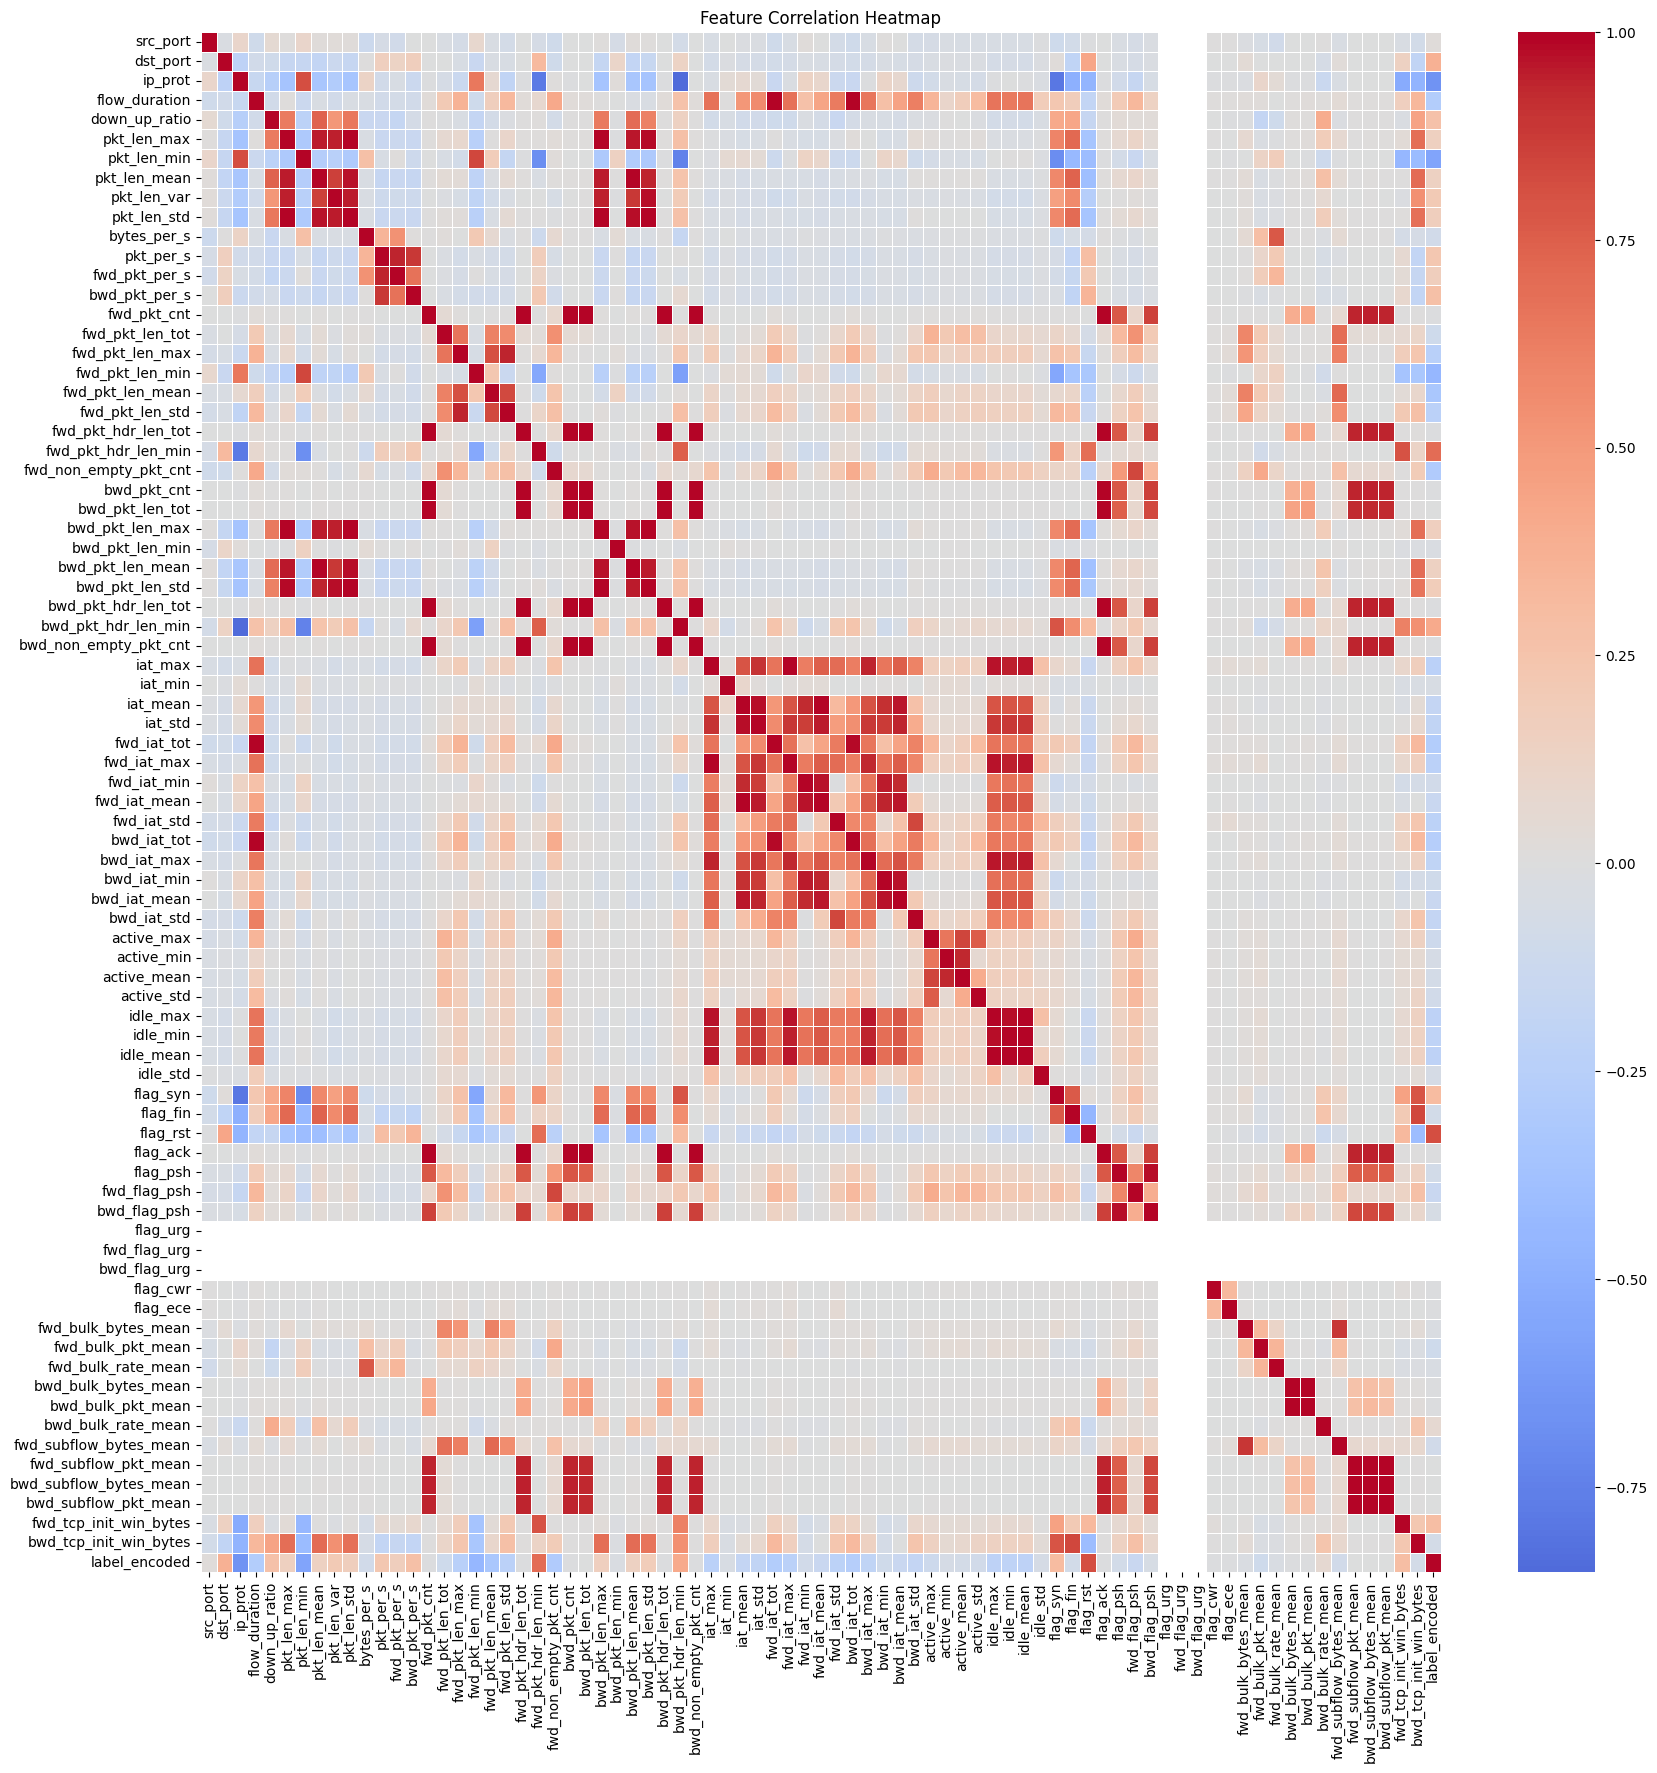

In [20]:
corr_matrix = plot_heatmap(copy_df)

In [21]:
## Seeing highly correlated 

def drop_highly_correlated_col(corr_matrix, threshold=0.93):
    # Find coordinates of all values above the threshold
    high_corr = np.where(np.abs(corr_matrix) > threshold)
    
    # Use a set comprehension to grab ONLY the column names (y-axis)
    # The 'if x != y and x < y' keeps only the upper triangle
    cols_to_drop = {
        corr_matrix.columns[y] 
        for x, y in zip(*high_corr) 
        if x != y and x < y
    }
    
    # Convert back to a list so it can be passed directly into df.drop()
    return list(cols_to_drop)

In [23]:
high_corr_col_df = drop_highly_correlated_col(corr_matrix)
len(high_corr_col_df)

31

In [24]:
df = df.drop(columns=high_corr_col_df)
df.shape

(542962, 49)

In [27]:
df.drop(columns=['label_encoded'],inplace=True)

In [31]:
df['label'].value_counts()

label
benign      286438
portscan    160106
ddos         95683
bot            735
Name: count, dtype: int64

## Handling infinity value

In [ ]:
df['label'] = le.inverse_transform(df['label_encoded']) #
df.drop(columns=['label_encoded'],inplace=True) #

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(numeric_features,'\n',categorical_features)

# Prepare the data
X = df[numeric_features]
y = df['label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


def replace_infinity(X):
    # np.isinf() catches both positive and negative infinity safely
    return np.where(np.isinf(X), np.nan, X)

inf_to_nan_transformer = FunctionTransformer(replace_infinity)    # To put custom Pandas/NumPy function into a Scikit-Learn pipeline, we wrap it in FunctionTransformer.

transformer = ColumnTransformer(
    transformers=[
        # (Name, Transformer Object, List of Columns)
        ("inf_to_nan", inf_to_nan_transformer, infinite_col)
    ],
    remainder='passthrough' # This tells it not to delete your other columns
)

transformer.set_output(transform="pandas")

X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes/s', 'flow_packets/s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length', 'bwd_header_length', 'fwd_packets/s', 'bwd_packets/s', 'min_packet_length', 'max_packet_length', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'fin_flag_count', 'syn_flag_count', 'rst_flag_count', 'psh_flag_count', 'ack_flag_count', 'urg_flag_count', 'cwe_flag_count', 'ece_flag_count

c:\Users\priyanshu\anaconda3\envs\venv\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:305: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))
c:\Users\priyanshu\anaconda3\envs\venv\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:305: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))


## Seeing Important Features

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

def important_features(df:pd.DataFrame):
    
    numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()
    print(numeric_features,'\n',categorical_features)

    # Prepare the data
    X = df[numeric_features]
    y = df['label']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    
    # Hyperparameter settings
    hyperparameters = {
        'n_estimators': 150,    # Number of trees
        'max_depth': 30,        # Limit tree depth
        'random_state': 42,     # For reproducibility
        'n_jobs': -1            # Use all available cores
    }


    # Create the Random Forest model with specified hyperparameters
    rf = RandomForestClassifier(**hyperparameters)

    # Fit the model on the training set
    rf.fit(X_train, y_train)

    # Cross-validation on the training set
    # cv_scores = cross_val_score(rf, X_train, y_train, cv=5, n_jobs=-1)
    # print(f'Cross-Validation Score: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')



    # Predict on test set
    y_pred = rf.predict(X_test)

    # Feature importances
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': numeric_features, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

    # Confusion matrix
    rf_labels = rf.classes_
    cm = confusion_matrix(y_test, y_pred)

    # Calculate test scores
    # rf_labels = le.inverse_transform(rf.classes_)
    report = classification_report(y_test, y_pred, target_names=rf_labels)
    print("\nClassification Report:\n")
    print(report, end='\n\n')

    # Plot feature importances
    plt.figure(figsize=(18, 12))
    plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.title('Feature Importance from Random Forest')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


    print(cm, rf_labels)
    return feature_importance_df

['src_port', 'dst_port', 'ip_prot', 'flow_duration', 'down_up_ratio', 'pkt_len_max', 'pkt_len_min', 'bytes_per_s', 'pkt_per_s', 'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_len_tot', 'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_hdr_len_min', 'fwd_non_empty_pkt_cnt', 'bwd_pkt_len_min', 'bwd_pkt_hdr_len_min', 'iat_max', 'iat_min', 'iat_mean', 'fwd_iat_min', 'fwd_iat_std', 'bwd_iat_std', 'active_max', 'active_min', 'active_std', 'idle_std', 'flag_syn', 'flag_fin', 'flag_rst', 'flag_psh', 'fwd_flag_psh', 'flag_urg', 'fwd_flag_urg', 'bwd_flag_urg', 'flag_cwr', 'flag_ece', 'fwd_bulk_bytes_mean', 'fwd_bulk_pkt_mean', 'fwd_bulk_rate_mean', 'bwd_bulk_bytes_mean', 'bwd_bulk_rate_mean', 'fwd_subflow_bytes_mean', 'fwd_tcp_init_win_bytes', 'bwd_tcp_init_win_bytes'] 
 ['label']

Classification Report:

              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     71610
         bot       1.00      1.00      1.00       184
        ddos       

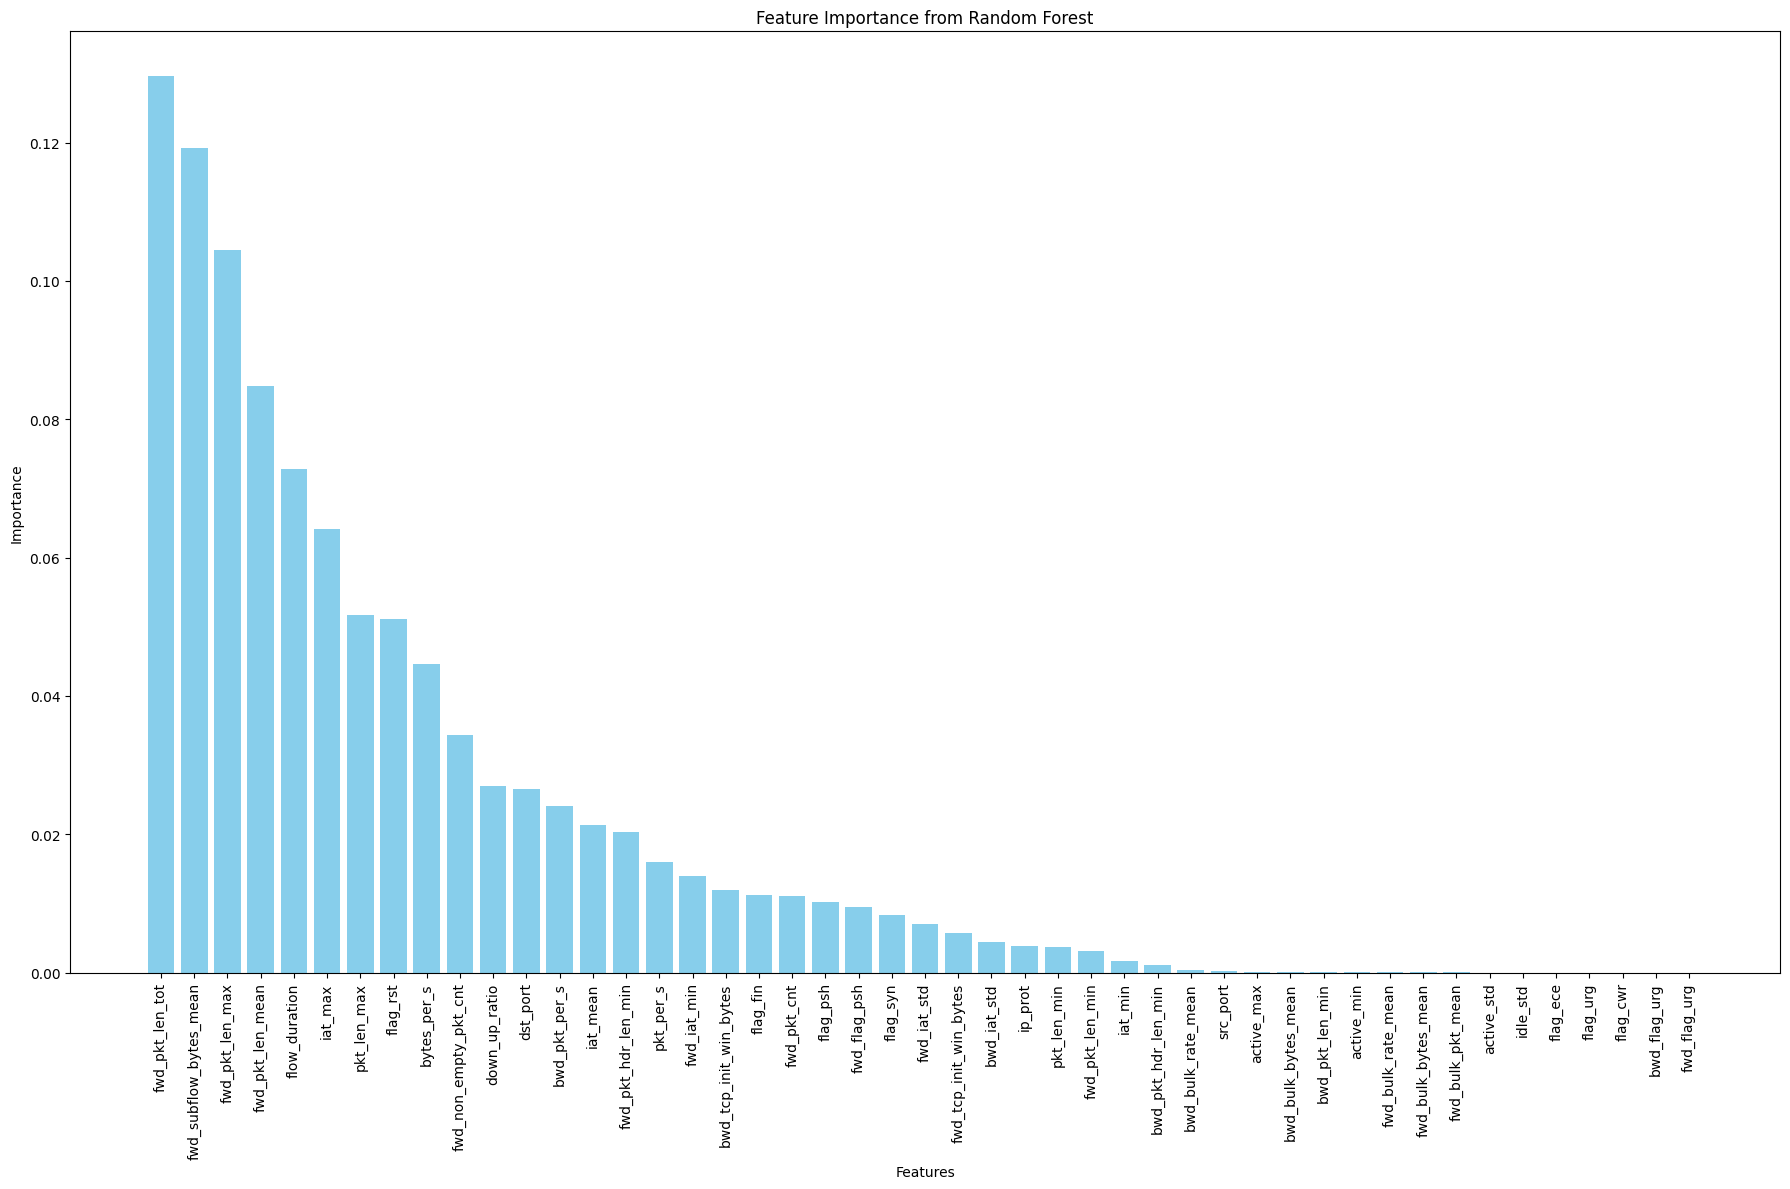

[[71610     0     0     0]
 [    0   184     0     0]
 [    0     0 23921     0]
 [    3     0     0 40023]] ['benign' 'bot' 'ddos' 'portscan']


,Feature,Importance
11,fwd_pkt_len_tot,0.129593
44,fwd_subflow_bytes_mean,0.119257
12,fwd_pkt_len_max,0.104452
14,fwd_pkt_len_mean,0.084832
3,flow_duration,0.072802
19,iat_max,0.064127
5,pkt_len_max,0.051681
31,flag_rst,0.051169
7,bytes_per_s,0.044662
16,fwd_non_empty_pkt_cnt,0.034320


In [29]:
important_features(df)

# ----Essential EDA---- 

In [18]:
master_df = pd.read_csv("../Artifacts/data_ingestion/feature_store/master_dataset.csv")
master_df.shape

(2830743, 79)

In [19]:
# 1. Count how many times each label appears
label_counts = master_df[' Label'].value_counts()
print(label_counts)

# 2. Find the labels that have at least 2 instances
valid_labels = label_counts[label_counts >= 2].index
print(valid_labels)

# 3. Filter the master dataset to only keep those valid labels
master_df = master_df[master_df[' Label'].isin(valid_labels)]

print(f"Removed rare classes. New shape: {master_df.shape}")

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Index(['BENIGN', 'DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye',
       'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest',
       'Bot', 'Web Attack � Brute Force', 'Web Attack � XSS', 'Infiltration',
       'Web Attack � Sql Injection', 'Heartbleed'],
      dtype='object', name=' Label')
Removed rare classes. New shape: (2830743, 79)


In [20]:
# Mapping the attacks to the new group
attack_mapping = {
    'BENIGN': 'Normal Traffic',
    'DDoS': 'DDoS',
    'PortScan': 'Port Scanning',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bots',
    'Web Attack � Brute Force': 'Web Attacks',
    'Web Attack � XSS': 'Web Attacks',
    'Web Attack � Sql Injection': 'Web Attacks',
    'Infiltration': 'Miscellaneous',
    'Heartbleed': 'Miscellaneous'
}

# 2. Apply it to the MASTER dataset
master_df[' Label'] = master_df[' Label'].replace(attack_mapping)

In [21]:
#Taking 10% of our master dataset, as processing 2.8M rows at every runs is computationally heavy
eda_sample, _ = train_test_split(master_df, train_size=0.10, stratify=master_df[' Label'], random_state=42)
eda_sample.shape

(283074, 79)

In [22]:
eda_sample.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [23]:
eda_sample.describe()

c:\Users\priyanshu\anaconda3\envs\venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\priyanshu\anaconda3\envs\venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,283074.000000,2.830740e+05,283074.000000,283074.000000,2.830740e+05,2.830740e+05,283074.000000,283074.000000,283074.000000,283074.000000,...,283074.000000,2.830740e+05,2.830740e+05,2.830740e+05,2.830740e+05,2.830740e+05,2.830740e+05,2.830740e+05,2.830740e+05,2.830740e+05
mean,8067.564110,1.485773e+07,8.112412,8.737118,5.447809e+02,1.219636e+04,207.177812,18.641698,58.256990,68.604320,...,4.978847,-5.665521e+02,8.196612e+04,4.154815e+04,1.542235e+05,5.845048e+04,8.339499e+06,4.927744e+05,8.712695e+06,7.950174e+06
std,18276.270185,3.373673e+07,585.687067,767.167780,5.023958e+03,1.702467e+06,709.881596,60.178055,186.658284,277.161651,...,564.065879,2.229720e+05,6.959206e+05,3.809895e+05,1.043667e+06,6.257905e+05,2.364749e+07,4.530394e+06,2.436654e+07,2.338665e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,1.550000e+02,2.000000,1.000000,1.200000e+01,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.132400e+04,2.000000,2.000000,6.200000e+01,1.230000e+02,37.000000,2.000000,34.000000,0.000000,...,1.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,3.266532e+06,5.000000,4.000000,1.880000e+02,4.840000e+02,81.000000,36.000000,50.000000,26.162951,...,2.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65534.000000,1.200000e+08,203943.000000,263412.000000,1.224076e+06,5.840000e+08,23360.000000,2065.000000,5939.285714,5816.000000,...,197124.000000,9.300000e+01,1.030000e+08,5.892773e+07,1.030000e+08,1.030000e+08,1.200000e+08,7.480000e+07,1.200000e+08,1.200000e+08


### Preprocessing

In [24]:
preprocess_column_name(eda_sample)

Index(['destination_port', 'flow_duration', 'total_fwd_packets',
       'total_backward_packets', 'total_length_of_fwd_packets',
       'total_length_of_bwd_packets', 'fwd_packet_length_max',
       'fwd_packet_length_min', 'fwd_packet_length_mean',
       'fwd_packet_length_std', 'bwd_packet_length_max',
       'bwd_packet_length_min', 'bwd_packet_length_mean',
       'bwd_packet_length_std', 'flow_bytes/s', 'flow_packets/s',
       'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min',
       'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max',
       'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std',
       'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags',
       'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length',
       'bwd_header_length', 'fwd_packets/s', 'bwd_packets/s',
       'min_packet_length', 'max_packet_length', 'packet_length_mean',
       'packet_length_std', 'packet_length_variance', 'fin_flag_count',
       'syn_flag_co

In [25]:
eda_sample['label'].value_counts()

label
Normal Traffic    227309
DoS                25266
Port Scanning      15893
DDoS               12803
Brute Force         1383
Web Attacks          218
Bots                 197
Miscellaneous          5
Name: count, dtype: int64

In [26]:
check_null_values(eda_sample)

['flow_bytes/s']


In [27]:
check_inf_values(eda_sample)

flow_bytes/s      147
flow_packets/s    290
dtype: int64
          flow_bytes/s  flow_packets/s
40494    379464.285700     4464.285714
2182337     302.882590        0.475017
132558      122.226218        0.122954
1060716    5283.757339       65.231572
1079897  965346.534700     9900.990099
...                ...             ...
1014913       0.000000    21978.021980
2441743  131147.541000    32786.885250
2792408       4.927857        0.821309
212884      125.059812        0.141573
1642251    1923.495634        7.730056

[283074 rows x 2 columns]


In [28]:
# Convert positive and negative infinity to NaN
eda_sample.replace([np.inf, -np.inf], np.nan, inplace=True)

### Making copy of eda sample to include encoded label

In [29]:
eda_sample_copy = eda_sample.copy()

In [30]:
eda_sample_copy.head()

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
40494,53,448,1,1,51,119,51,51,51.000000,0.000000,...,32,0.0,0.0000,0,0,0.0,0.0000,0,0,Normal Traffic
2182337,443,117890566,26,30,17786,17921,5520,0,684.076923,1350.491908,...,20,245997.5,225119.4646,405181,86814,58700000.0,224117.4943,58800000,58500000,Normal Traffic
132558,80,97597718,6,6,334,11595,334,0,55.666667,136.354929,...,32,93.0,0.0000,93,93,97400000.0,0.0000,97400000,97400000,DoS
1060716,53,61320,2,2,60,264,30,30,30.000000,0.000000,...,20,0.0,0.0000,0,0,0.0,0.0000,0,0,Normal Traffic
1079897,53,404,2,2,72,318,36,36,36.000000,0.000000,...,32,0.0,0.0000,0,0,0.0,0.0000,0,0,Normal Traffic


### Removing highly correlated rows

In [31]:
eda_sample_copy = label_encoding(eda_sample_copy)
print(eda_sample_copy['label_encoded'])
eda_sample_copy.columns

40494      5
2182337    5
132558     3
1060716    5
1079897    5
          ..
1014913    5
2441743    6
2792408    2
212884     3
1642251    5
Name: label_encoded, Length: 283074, dtype: int64


Index(['destination_port', 'flow_duration', 'total_fwd_packets',
       'total_backward_packets', 'total_length_of_fwd_packets',
       'total_length_of_bwd_packets', 'fwd_packet_length_max',
       'fwd_packet_length_min', 'fwd_packet_length_mean',
       'fwd_packet_length_std', 'bwd_packet_length_max',
       'bwd_packet_length_min', 'bwd_packet_length_mean',
       'bwd_packet_length_std', 'flow_bytes/s', 'flow_packets/s',
       'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min',
       'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max',
       'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std',
       'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags',
       'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length',
       'bwd_header_length', 'fwd_packets/s', 'bwd_packets/s',
       'min_packet_length', 'max_packet_length', 'packet_length_mean',
       'packet_length_std', 'packet_length_variance', 'fin_flag_count',
       'syn_flag_co

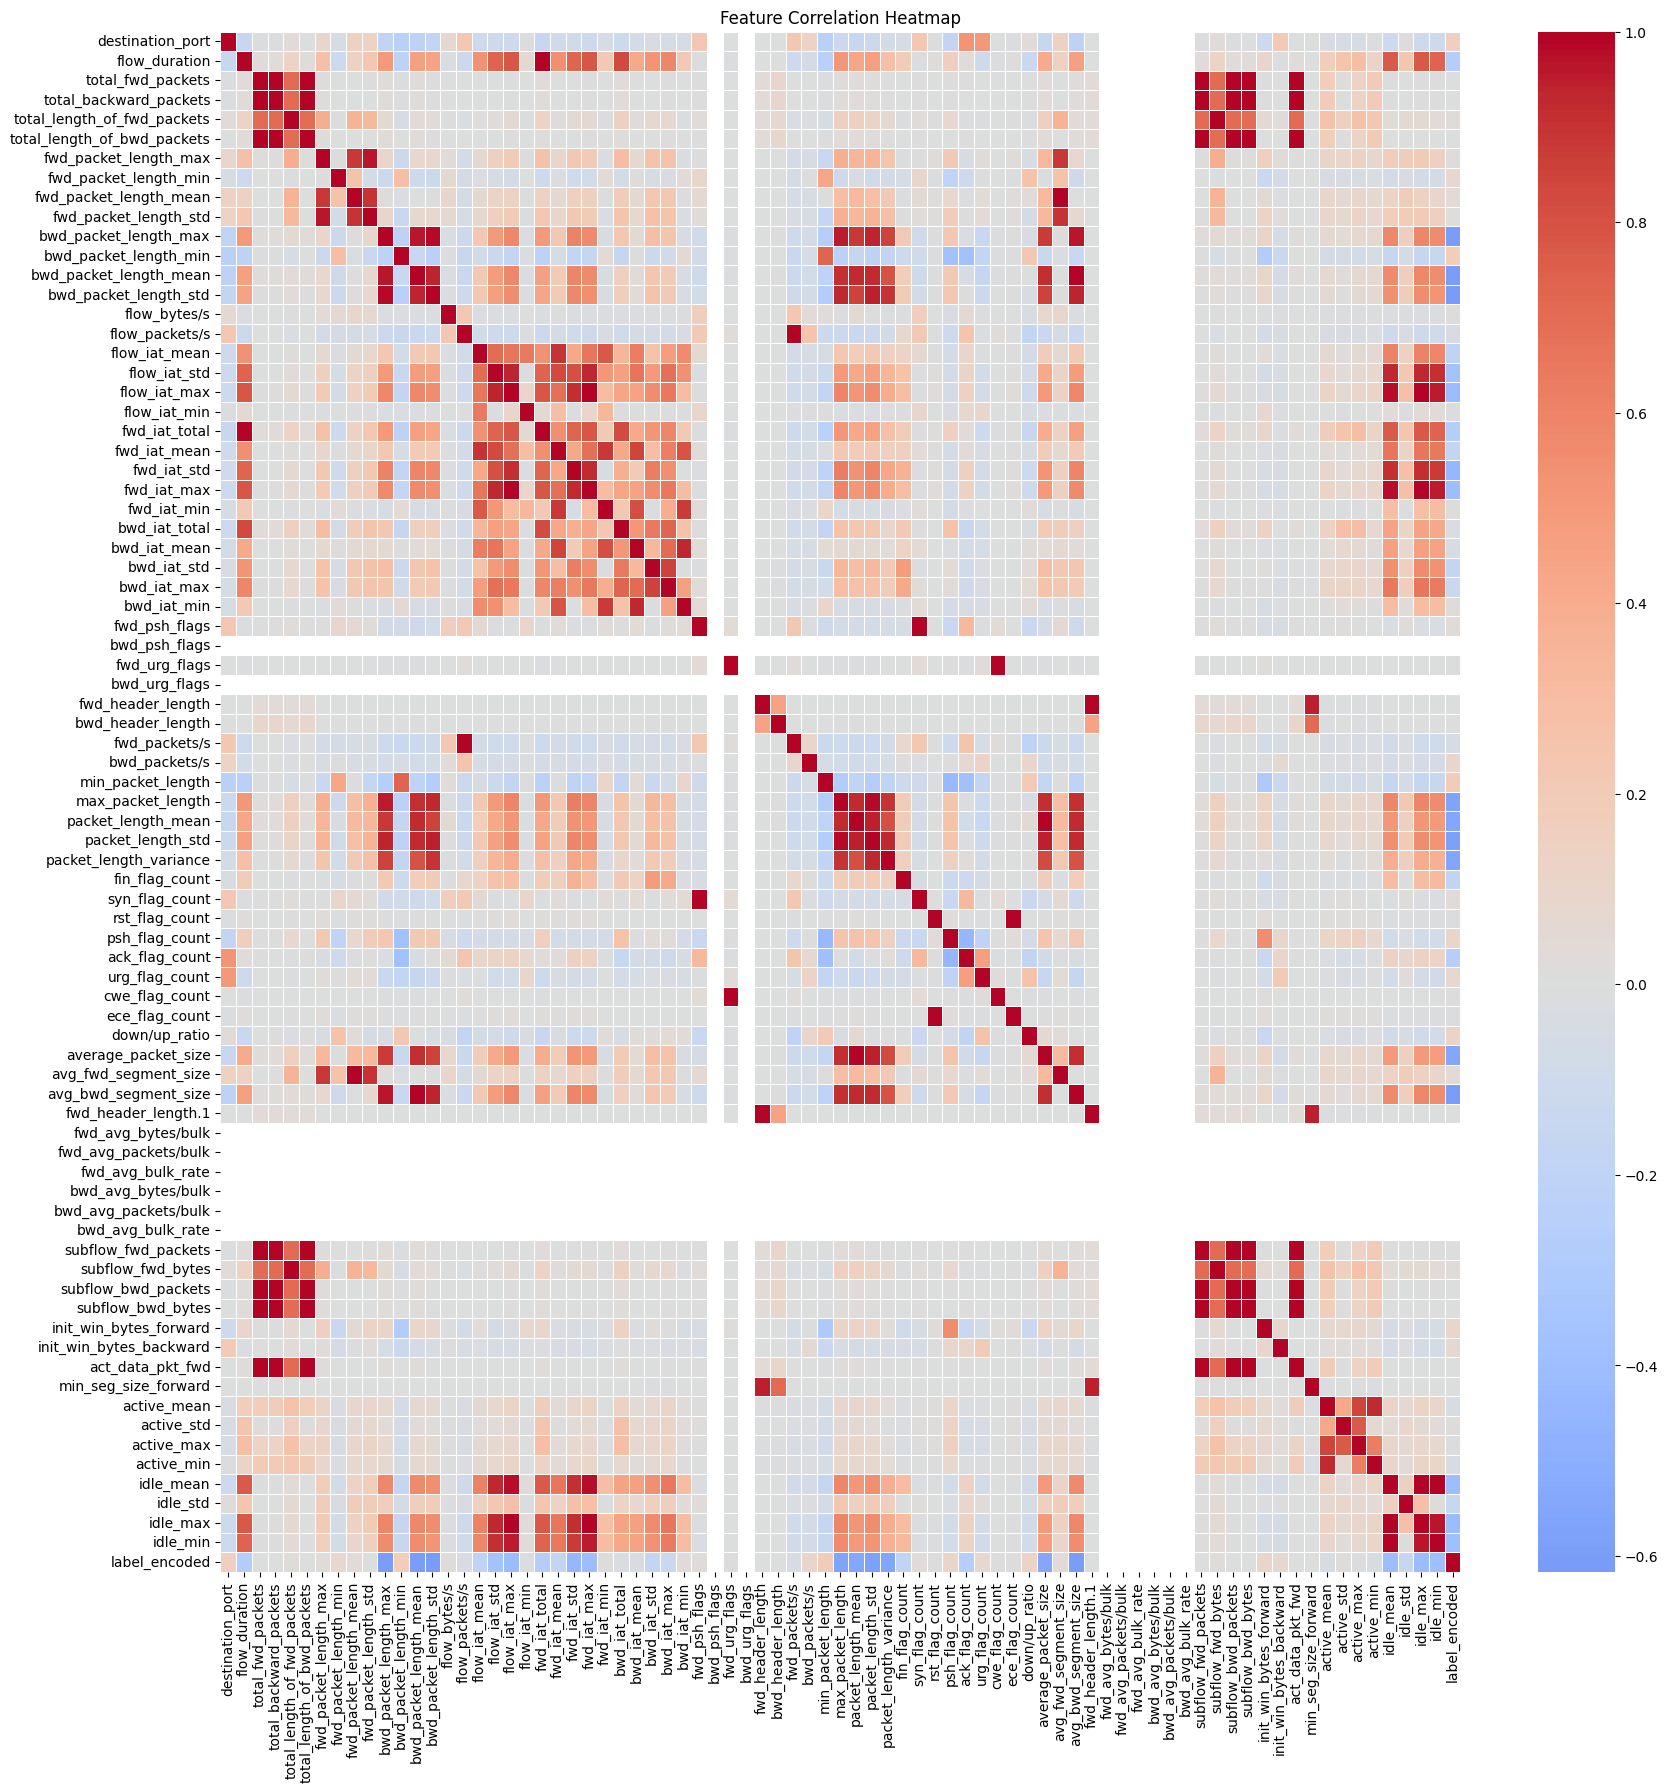

In [32]:
corr_matrix = plot_heatmap(eda_sample_copy)

In [33]:
highly_correlated_rows = drop_highly_correlated_col(corr_matrix=corr_matrix)
print(highly_correlated_rows)

['fwd_iat_max', 'idle_min', 'subflow_fwd_bytes', 'idle_mean', 'fwd_iat_std', 'ece_flag_count', 'subflow_bwd_bytes', 'fwd_packet_length_mean', 'packet_length_mean', 'total_length_of_bwd_packets', 'avg_fwd_segment_size', 'packet_length_variance', 'average_packet_size', 'subflow_fwd_packets', 'fwd_iat_mean', 'idle_max', 'subflow_bwd_packets', 'min_seg_size_forward', 'fwd_iat_min', 'flow_iat_max', 'bwd_iat_min', 'bwd_packet_length_std', 'fwd_header_length.1', 'cwe_flag_count', 'fwd_packets/s', 'avg_bwd_segment_size', 'max_packet_length', 'act_data_pkt_fwd', 'packet_length_std', 'fwd_packet_length_std', 'fwd_iat_total', 'bwd_packet_length_mean', 'syn_flag_count', 'active_min', 'total_backward_packets', 'bwd_iat_max']


In [34]:
eda_sample.drop(columns=highly_correlated_rows,axis=1,inplace=True)
eda_sample.shape

(283074, 43)

### Checking and handling nan values

In [35]:
(eda_sample.isna().sum() / len(eda_sample)) * 100

destination_port               0.000000
flow_duration                  0.000000
total_fwd_packets              0.000000
total_length_of_fwd_packets    0.000000
fwd_packet_length_max          0.000000
fwd_packet_length_min          0.000000
bwd_packet_length_max          0.000000
bwd_packet_length_min          0.000000
flow_bytes/s                   0.102447
flow_packets/s                 0.102447
flow_iat_mean                  0.000000
flow_iat_std                   0.000000
flow_iat_min                   0.000000
bwd_iat_total                  0.000000
bwd_iat_mean                   0.000000
bwd_iat_std                    0.000000
fwd_psh_flags                  0.000000
bwd_psh_flags                  0.000000
fwd_urg_flags                  0.000000
bwd_urg_flags                  0.000000
fwd_header_length              0.000000
bwd_header_length              0.000000
bwd_packets/s                  0.000000
min_packet_length              0.000000
fin_flag_count                 0.000000


Since value of na value is so less(less than 5% of data). Therefore, we will drop na values

In [36]:
eda_sample.dropna(inplace=True)
eda_sample.shape

(282784, 43)

### Important Features

['destination_port', 'flow_duration', 'total_fwd_packets', 'total_length_of_fwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'bwd_packet_length_max', 'bwd_packet_length_min', 'flow_bytes/s', 'flow_packets/s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length', 'bwd_header_length', 'bwd_packets/s', 'min_packet_length', 'fin_flag_count', 'rst_flag_count', 'psh_flag_count', 'ack_flag_count', 'urg_flag_count', 'down/up_ratio', 'fwd_avg_bytes/bulk', 'fwd_avg_packets/bulk', 'fwd_avg_bulk_rate', 'bwd_avg_bytes/bulk', 'bwd_avg_packets/bulk', 'bwd_avg_bulk_rate', 'init_win_bytes_forward', 'init_win_bytes_backward', 'active_mean', 'active_std', 'active_max', 'idle_std'] 
 ['label']

Classification Report:

                precision    recall  f1-score   support

          Bots       0.89      0.65      0.75        49
   Brute Force       1.00      0

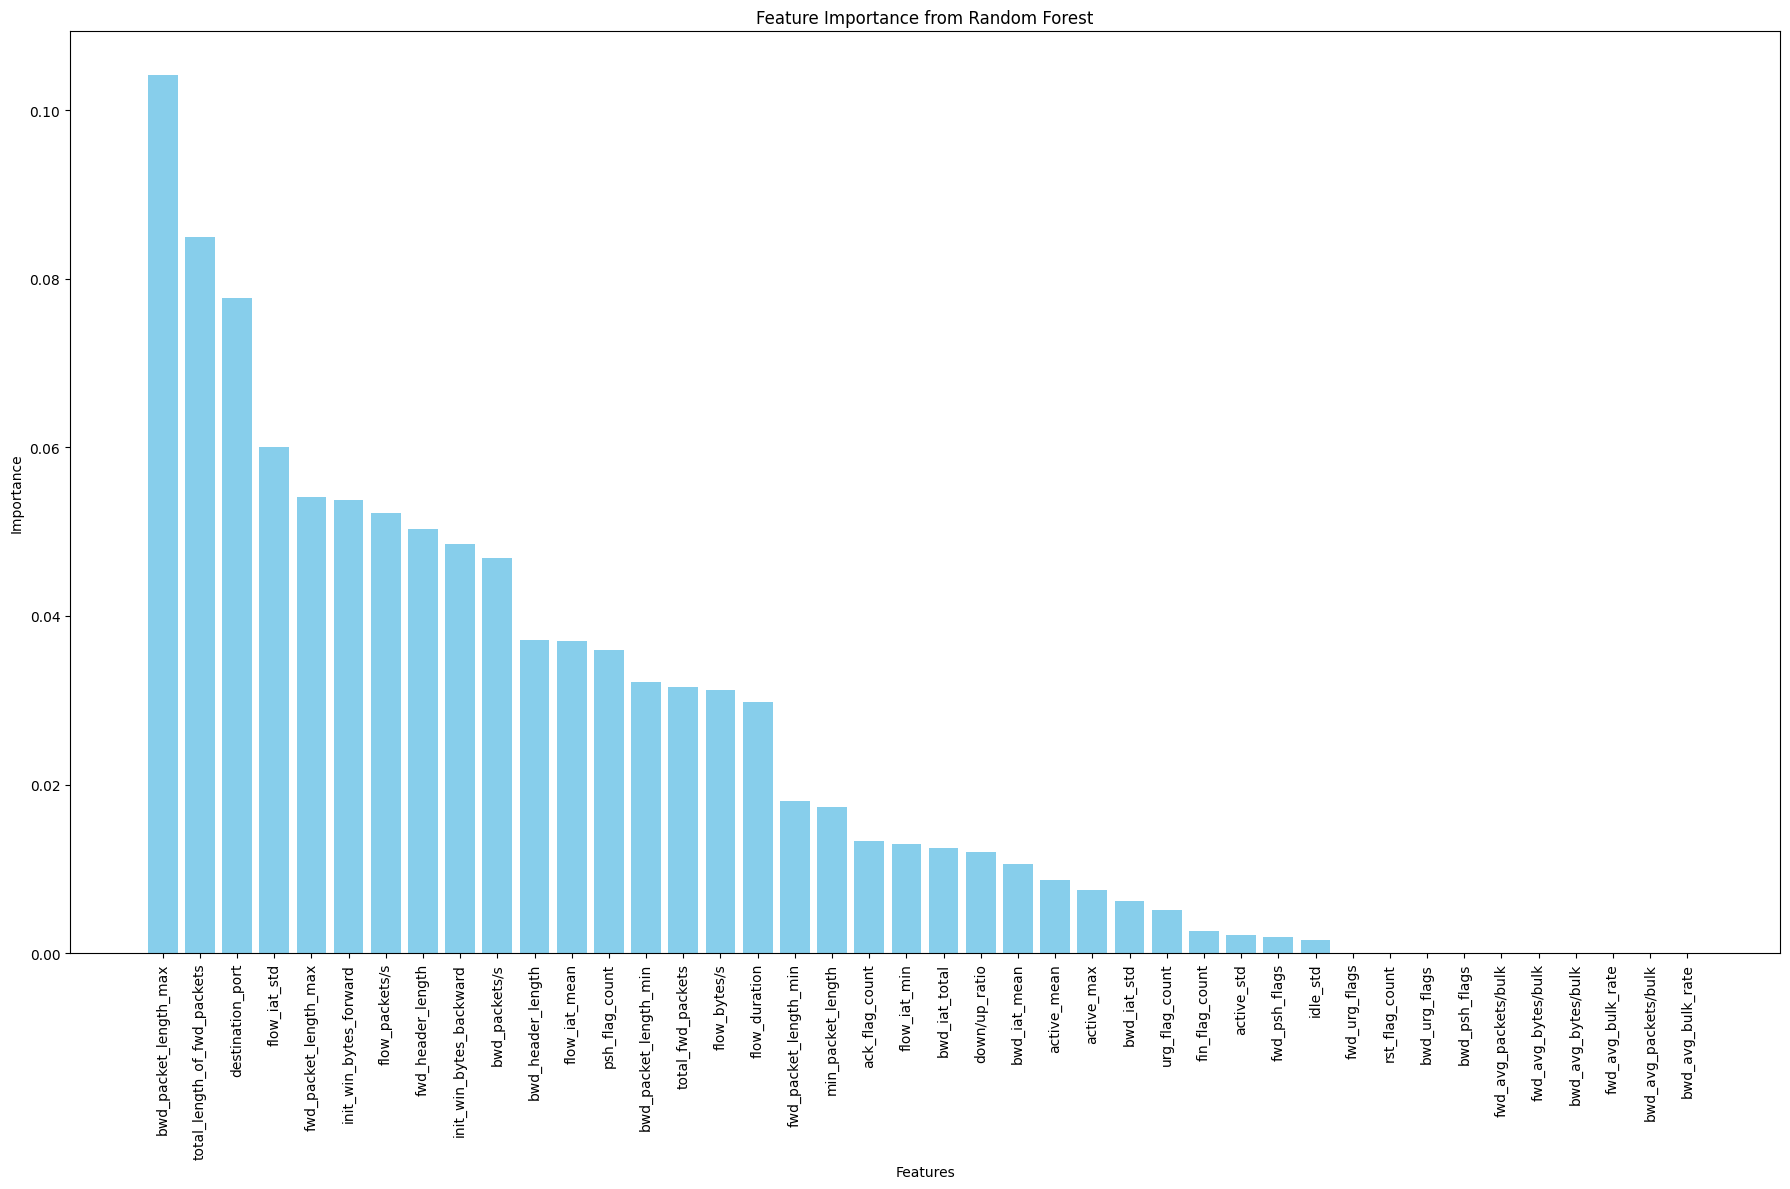

[[   32     0     0     0     0    17     0     0]
 [    0   343     0     0     0     2     0     0]
 [    0     0  3195     0     0     6     0     0]
 [    0     0     0  6276     0    15     0     0]
 [    0     0     0     0     1     0     0     0]
 [    4     0     0    15     0 56741    23     3]
 [    0     0     1     0     0    19  3947     1]
 [    0     0     0     0     0    12     0    43]] ['Bots' 'Brute Force' 'DDoS' 'DoS' 'Miscellaneous' 'Normal Traffic'
 'Port Scanning' 'Web Attacks']


In [39]:
top_important_features = important_features(eda_sample)

# Saving 20 Important features to top_features.yaml
### All the 78 features will be stored in schema.yaml

In [53]:
# 1. Grab your top 20 features (assuming 'Feature' column holds the original names)
imp_features = top_important_features['Feature'].head(20).tolist()

# 2. Build the dictionary using the original dataset to get the correct data types
top_20_features = {feature: str(eda_sample[feature].dtype) for feature in imp_features}

# 3. Add the original target label name 
top_20_features['label'] = str(eda_sample['label'].dtype)

print(top_20_features)

{'bwd_packet_length_max': 'int64', 'total_length_of_fwd_packets': 'int64', 'destination_port': 'int64', 'flow_iat_std': 'float64', 'fwd_packet_length_max': 'int64', 'init_win_bytes_forward': 'int64', 'flow_packets/s': 'float64', 'fwd_header_length': 'int64', 'init_win_bytes_backward': 'int64', 'bwd_packets/s': 'float64', 'bwd_header_length': 'int64', 'flow_iat_mean': 'float64', 'psh_flag_count': 'int64', 'bwd_packet_length_min': 'int64', 'total_fwd_packets': 'int64', 'flow_bytes/s': 'float64', 'flow_duration': 'int64', 'fwd_packet_length_min': 'int64', 'min_packet_length': 'int64', 'ack_flag_count': 'int64', 'label': 'object'}


### Storing important features in top_features.yaml

In [55]:
write_yaml_file(file_path="../data_schema/top_features.yaml",content=top_20_features, replace=True)

### Storing all the 78 features and 1 label in schema.yaml

In [57]:
test_df = pd.read_csv("../Artifacts/data_ingestion/ingested/test.csv")
test_df_col = test_df.columns
schema_dict = {feature: str(test_df[feature].dtype) for feature in test_df_col}
print(len(schema_dict))

79


In [58]:
write_yaml_file(file_path="../data_schema/schema.yaml",content=schema_dict, replace=True)